# Two-Phase Flow Simulator

In [1]:
from __future__ import division
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython import display
import scipy.sparse as sp
import scipy.sparse.linalg
from scipy.linalg import solve_banded
import time
%matplotlib inline
from IPython.core.debugger import set_trace
plt.rcParams['figure.dpi'] = 100

In [2]:
def tic():
    #Homemade version of matlab tic and toc functions
    import time
    global startTime_for_tictoc
    startTime_for_tictoc = time.time()

def toc():
    import time
    if 'startTime_for_tictoc' in globals():
        print("Elapsed time is " + str(time.time() - startTime_for_tictoc) + " seconds.")
    else:
        print("Toc: start time not set")

Define domain size and number of grid cells in each direction:

In [3]:
Lx = 30
Ly = 20
Lz = 10

Nx = 30
Ny = 20
Nz = 3

N = Nx*Ny*Nz

Simulation run parameters:

In [4]:
tmax = 0.7
nrsteps = 30

Fluid properties:

In [5]:
krw0 = 0.9
kro0 = 0.7
nw = 1
no = 2
Swc = 0.1
Sor = 0.2

viscw = 1
visco = 0.5

Relative permeabilities, mobilities, fractional flow:

In [6]:
def relperm(S,Swc,Sor,krw0,kro0,nw,no):
    Seff = (S - Swc) / (1 - Swc - Sor)
    krw = krw0*Seff**nw
    kro = kro0*(1-Seff)**no
    return krw, kro

def mobility(S,Swc,Sor,krw0,kro0,nw,no,viscw,visco):
    krw, kro = relperm(S,Swc,Sor,krw0,kro0,nw,no)
    mobw = krw/viscw
    mobo = kro/visco
    return mobw, mobo, mobw+mobo

def fracflow(S,Swc,Sor,krw0,kro0,nw,no,viscw,visco):
    mobw, mobo, mobtot = mobility(S,Swc,Sor,krw0,kro0,nw,no,viscw,visco)
    return mobw/mobtot, mobo/mobtot


def dfdS(S,Swc,Sor,krw0,kro0,nw,no,viscw,visco):
    mobw, mobo, mobtot = mobility(S,Swc,Sor,krw0,kro0,nw,no,viscw,visco)
    Seff = (S - Swc) / (1 - Swc - Sor)
    dMw =   nw*krw0 *     Seff**(nw-1) / (1 - Swc - Sor) / viscw
    dMo = - no*kro0 * (1-Seff)**(no-1) / (1 - Swc - Sor) / visco
    df = dMw / mobtot -   mobw/mobtot**2 *(dMw+dMo)
    return df

Test and plot

Maximum slope of fractional flow by FD is: 2.11
Maximum slope of fractional flow is exactly: 2.11


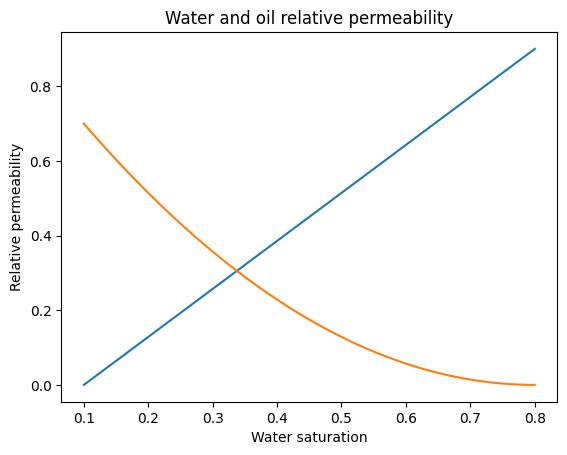

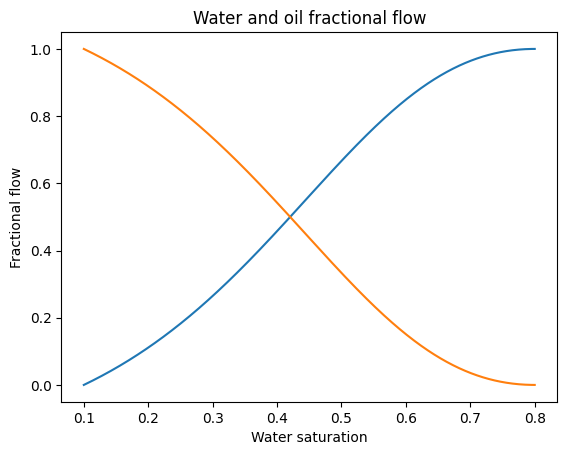

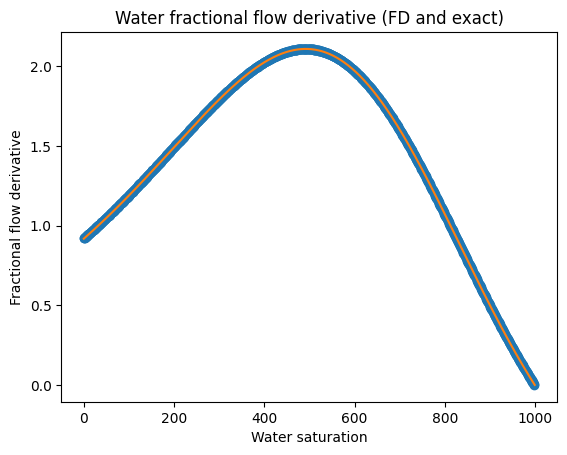

In [7]:
# Full range of (allowable) saturations:
Sw = np.linspace(Swc,1-Sor,1000)

# Plot results?
plot_fluid_funcs = True

# Compute relative permeabilities:
krw, kro = relperm(Sw,Swc,Sor,krw0,kro0,nw,no)

# Plot rel perms:
if plot_fluid_funcs:
    plt.figure()
    plt.plot(Sw,krw)
    plt.plot(Sw,kro)

    plt.title("Water and oil relative permeability")
    plt.xlabel("Water saturation")
    plt.ylabel("Relative permeability")


# Compute fractional flow functions:
fw, fo = fracflow(Sw,Swc,Sor,krw0,kro0,nw,no,viscw,visco)

# Plot fractional flows:
if plot_fluid_funcs:
    plt.figure()
    plt.plot(Sw,fw)
    plt.plot(Sw,fo)

    plt.title("Water and oil fractional flow")
    plt.xlabel("Water saturation")
    plt.ylabel("Fractional flow")

maxdfdS = np.max((fw[1:]-fw[0:-1])/(Sw[1:]-Sw[0:-1]))
maxdf   = np.max(dfdS(Sw,Swc,Sor,krw0,kro0,nw,no,viscw,visco))
print("Maximum slope of fractional flow by FD is:", round(maxdfdS,2))

if plot_fluid_funcs:
    plt.figure()
    plt.plot((fw[1:]-fw[0:-1])/(Sw[1:]-Sw[0:-1]),'o')
    plt.plot(dfdS(Sw,Swc,Sor,krw0,kro0,nw,no,viscw,visco))
    plt.title("Water fractional flow derivative (FD and exact)")
    plt.xlabel("Water saturation")
    plt.ylabel("Fractional flow derivative")

print("Maximum slope of fractional flow is exactly:", round(maxdf,2))

Define boundary conditions, in terms of injection and production rates in certain wells:

In [8]:
Qijk = np.zeros((Nx,Ny,Nz))
# First in ijk index notation for user convenience:
Qijk[0,0,0]    = 0.1
Qijk[Nx-1,Ny-1,Nz-1] = -0.1
# But in the numerical solver we'll need this to be a column vector:
Q = Qijk.reshape((N,1))

A permeability field that allows for three (3!) values per grid cell, i.e. different permeabilities in the x, y, and z directions, for each grid cell.


In [9]:
K = np.ones((3,Nx,Ny,Nz))
K[1,:,:,:] = K[1,:,:,:]/100
poros = 0.2*np.ones((N,1))
gridV = Lx*Ly*Lz/N
gridPV = gridV*poros
PVtot = np.sum(gridPV)

Now we convert from convenient user-input units to the SI units used in the mathematical formulation:

In [10]:
year = 1./(60*60*24*365)
# Rates from fraction PV/yr to m3/sec
Q = Q*PVtot*year
# Just the (positive) injection rates:
inj = sum(Q.clip(min=0))
# Duration of simulation from fraction PV injection to secs.
tmax = tmax*PVtot/inj
# Permeability from mDarcy to m2:
milliDarcy = 10e-15
K = K*milliDarcy
# Viscosities from centiPoise to Pa s
viscw = viscw/1000
visco = visco/1000

In [11]:
K[1,1,1,1]

np.float64(1e-16)

Here is the main Two-Point-Flux-Approximation algorithm:

In [12]:
def TPFA(Lx,Ly,Lz,Nx,Ny,Nz,Q,K):
    dx = Lx/Nx
    dy = Ly/Ny
    dz = Lz/Nz

    # To compute harmonic average of permeabilities (below) it is useful to define
    # the inverse of permeability as its onwn variable:
    invK = 1./K

    # The transmissibility factors (below) involve the surface area of a face
    # perpendicular to the flow direction (i.e., dy*dz for flow in the x direction)
    # and the reciprocal of a grid cell width in that direction, which comes from the
    # finite difference derivative in that direction. For each dimension, we have:
    tx = 2*dy*dz/dx
    ty = 2*dx*dz/dy
    tz = 2*dx*dy/dz

    TX = np.zeros((Nx+1,Ny,Nz))
    TY = np.zeros((Nx,Ny+1,Nz))
    TZ = np.zeros((Nx,Ny,Nz+1))

    TX[1:Nx,:,:]    = tx / (invK[0,0:Nx-1,:,:] + invK[0,1:Nx,:,:])
    TY[:,1:Ny,:]    = ty / (invK[1,:,0:Ny-1,:] + invK[1,:,1:Ny,:])
    TZ[:,:,1:Nz]    = tz / (invK[2,:,:,0:Nz-1] + invK[2,:,:,1:Nz])

    x1 = TX[0:Nx,:,:].reshape(N,order='F')
    y1 = TY[:,0:Ny,:].reshape(N,order='F')
    z1 = TZ[:,:,0:Nz].reshape(N,order='F')

    x2 = TX[1:Nx+1,:,:].reshape(N,order='F')
    y2 = TY[:,1:Ny+1,:].reshape(N,order='F')
    z2 = TZ[:,:,1:Nz+1].reshape(N,order='F')

    maindiag = x1+x2+y1+y2+z1+z2
    maindiag[0] = maindiag[0] + np.sum(K[:,0,0,0])
    DiagVecs = [-z2[0:-Nx*Ny],-y2[0:-Nx],-x2[0:-1],maindiag,-x1[1:],-y1[Nx:],-z1[Nx*Ny:]]
    DiagIndx = [-Nx*Ny,-Nx,-1,0,1,Nx,Nx*Ny]

    A = sp.diags(DiagVecs, DiagIndx)
    # print(A.toarray())

    pvec = sp.linalg.spsolve(A, Q)
    P = pvec.reshape(Nx,Ny,Nz,order='F')
    # print(P)

    Vx = np.zeros((Nx+1,Ny,Nz))
    Vy = np.zeros((Nx,Ny+1,Nz))
    Vz = np.zeros((Nx,Ny,Nz+1))
    Vx[1:Nx,:,:] = (P[0:Nx-1,:,:]-P[1:Nx,:,:])*TX[1:Nx,:,:]
    Vy[:,1:Ny,:] = (P[:,0:Ny-1,:]-P[:,1:Ny,:])*TY[:,1:Ny,:]
    Vz[:,:,1:Nz] = (P[:,:,0:Nz-1]-P[:,:,1:Nz])*TZ[:,:,1:Nz]
    return P, Vx, Vy, Vz

In [13]:
P, Vx, Vy, Vz = TPFA(Lx,Ly,Lz,Nx,Ny,Nz,Q,K)

/tmp/ipykernel_222/1644371135.py:42: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  pvec = sp.linalg.spsolve(A, Q)


In [14]:
def upwindingmatrix(Nx,Ny,Nz,Vx,Vy,Vz,Q,maxdfdS):
    N = Nx*Ny*Nz

    inj_well  = Q.clip(min=0).transpose()
    prod_well = Q.clip(max=0).transpose()

    XN = Vx.clip(max=0)
    YN = Vy.clip(max=0)
    ZN = Vz.clip(max=0)

    XP = Vx.clip(min=0)
    YP = Vy.clip(min=0)
    ZP = Vz.clip(min=0)

    x1 = XN[0:Nx,:,:].reshape(N,order='F')
    y1 = YN[:,0:Ny,:].reshape(N,order='F')
    z1 = ZN[:,:,0:Nz].reshape(N,order='F')

    x2 = XP[1:Nx+1,:,:].reshape(N,order='F')
    y2 = YP[:,1:Ny+1,:].reshape(N,order='F')
    z2 = ZP[:,:,1:Nz+1].reshape(N,order='F')

    maindiag = x1-x2+y1-y2+z1-z2 + prod_well
    DiagVecs = [z2[0:-Nx*Ny],y2[0:-Nx],x2[0:-1],maindiag,-x1[1:],-y1[Nx:],-z1[Nx*Ny:]]
    DiagIndx = [-Nx*Ny,-Nx,-1,0,1,Nx,Nx*Ny]

    UPW = sp.diags(DiagVecs, DiagIndx)

    fromleft = XP[0:Nx,:,:] + YP[:,0:Ny,:] + ZP[:,:,0:Nz]
    fromright = - XN[1:Nx+1,:,:] - YN[:,1:Ny+1,:] - ZN[:,:,1:Nz+1]
    Vin = (fromleft + fromright).reshape(N,order='F') + inj_well

    CFL = np.min(gridPV/Vin)/maxdfdS
    return UPW, CFL

In [15]:
# fullUPW = UPW.toarray()
# print(fullUPW)
def SV_plot(Lx,Ly,Lz,Nx,Ny,Nz,P,Vx,Vy,Vz,iter):

    XX = np.linspace(0,Lx,Nx)
    YY = np.linspace(0,Ly,Ny)
    ZZ = np.linspace(0,Lz,Nz)

    # Define center velocities:
    VcX = np.zeros((Nx, Ny, Nz))
    VcY = np.zeros((Nx, Ny, Nz))
    VcZ = np.zeros((Nx, Ny, Nz))
    VcX[0:Nx,:,:] = (Vx[0:Nx,:,:]+Vx[1:Nx+1,:,:])/2
    VcY[:,0:Ny,:] = (Vy[:,0:Ny,:]+Vy[:,1:Ny+1,:])/2
    VcZ[:,:,0:Nz] = (Vz[:,:,0:Nz]+Vz[:,:,1:Nz+1])/2

    # Define a slice location to allow 2D plots:
    sliceat = int(np.floor(Nz/2))
    P_2D = np.squeeze(P[:,:,sliceat]).transpose()
    Vx_2D = np.squeeze(VcX[:,:,sliceat]).transpose()
    Vy_2D = np.squeeze(VcY[:,:,sliceat]).transpose()

    # Pressure plot:
    plt.contourf(XX,YY,P_2D)
    # Velocity field:
    plt.quiver(XX,YY,Vx_2D,Vy_2D)

    it = str("{:02d}".format(iter))
    title = 'Saturation contours and velocities for iter='+it
    plt.title(title)
    plt.savefig("frame"+it+".png")


/tmp/ipykernel_222/1644371135.py:42: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  pvec = sp.linalg.spsolve(A, Q)
/tmp/ipykernel_222/379548095.py:28: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Nt = int(np.ceil(dtbig/CFL))


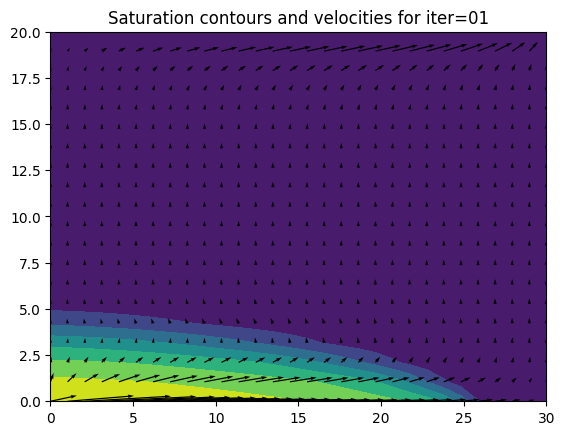

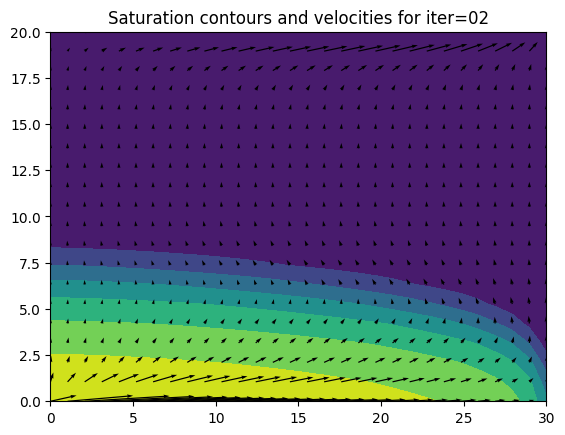

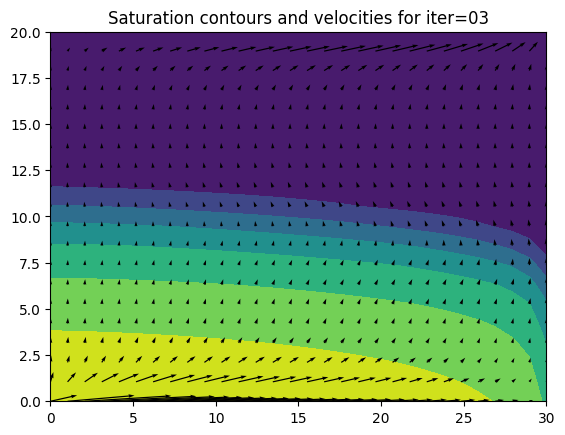

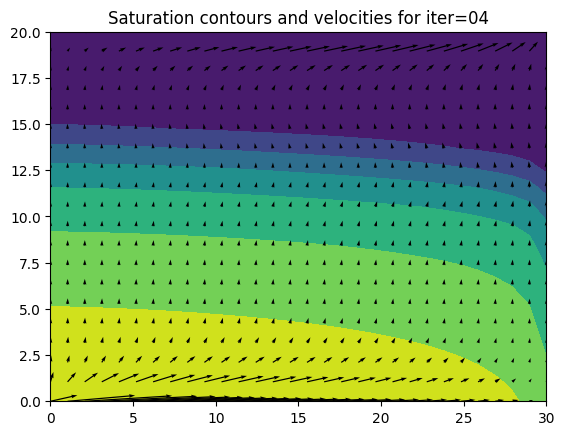

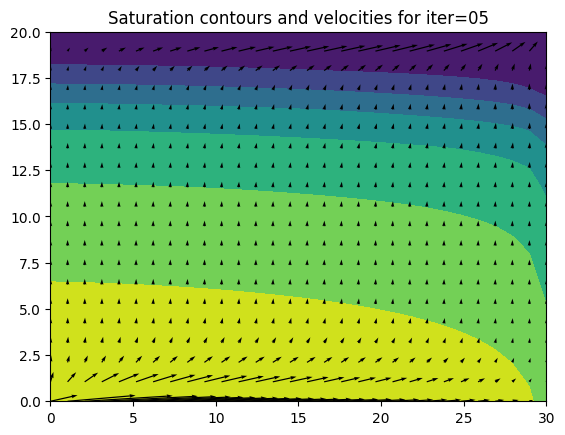

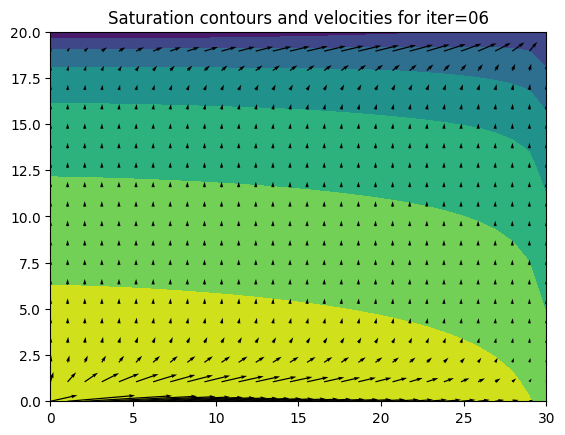

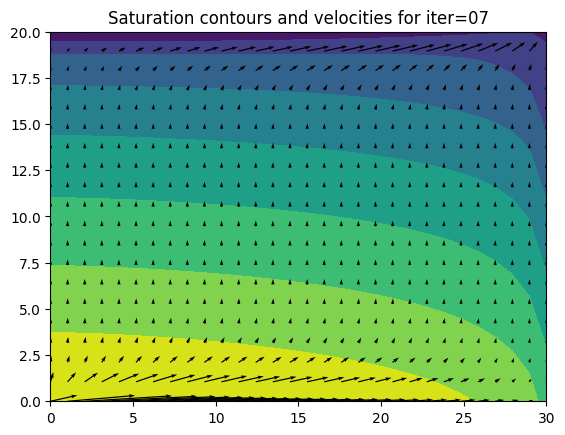

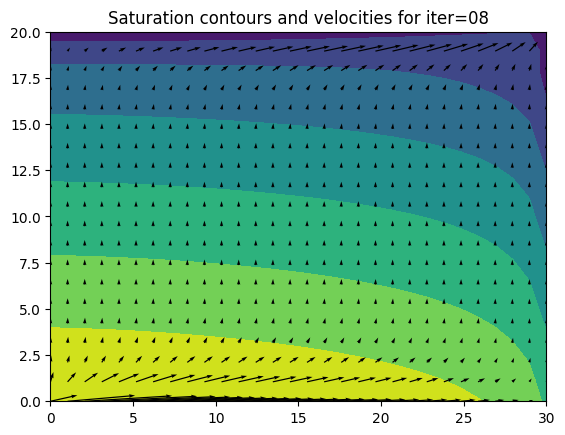

Simulation finished
Elapsed time is 29.844974756240845 seconds.


In [16]:
tic()
dtbig = tmax/nrsteps
sliceat = int(np.floor(Nz/2))
XX = np.linspace(0,Lx,Nx)
YY = np.linspace(0,Ly,Ny)
ZZ = np.linspace(0,Lz,Nz)
Sat = Swc*np.ones((N,1))
Ssave = Sat

fig = plt.figure()
# plt.xlabel('x(m)')
# plt.ylabel('y(m)')
plot_at = np.ceil(nrsteps / 8)
k=1

iter = 1
while iter < nrsteps+1:
    dum, dum, mt = mobility(Sat,Swc,Sor,krw0,kro0,nw,no,viscw,visco)

    mobs = np.asarray([mt,mt,mt])
    mobs = mobs.reshape(3,Nx,Ny,Nz,order='F')
    Keff = mobs * K

    P, Vx, Vy, Vz = TPFA(Lx,Ly,Lz,Nx,Ny,Nz,Q,Keff)

    UPW, CFL = upwindingmatrix(Nx,Ny,Nz,Vx,Vy,Vz,Q,maxdfdS)

    Nt = int(np.ceil(dtbig/CFL))

    dtx = (dtbig/Nt) / gridPV
    inj_well  = Q.clip(min=0)

    for i in np.arange(0,Nt):
        fw, dum = fracflow(Sat,Swc,Sor,krw0,kro0,nw,no,viscw,visco)
        upwfw = UPW.dot(fw)
        Sat = Sat + (UPW.dot(fw) + inj_well) * dtx

    # print("Big loop iteration", iter, " with ", Nt, "smaller (CFL) saturation updates.")
    iter = iter+1

    if iter % plot_at == 0 or iter == nrsteps:
        # print("This is where I plot", iter)

        plt.close("all")
        # plt.figure()
        plt.clf()
        # plt.xlabel('x(m)')
        # plt.ylabel('y(m)')
        S3D = Sat.reshape((Nx,Ny,Nz),order='F')
        SV_plot(Lx,Ly,Lz,Nx,Ny,Nz,S3D,Vx,Vy,Vz,k)

        # S3D = np.squeeze(S3D[:,:,sliceat]).transpose()
        # ax.contourf(XX,YY,S3D)
        #
        # fig.canvas.draw_idle()
        # plt.pause(1)
        # title = 'Saturation contours and velocities for iter='+str(iter)
        # plt.title(title)
        # plt.show()
        plt.show(block=False)
        plt.pause(3)
        plt.close()
        k = k+1
        # plt.close(fig)
        # display.display(plt.gcf())
        # plt.gcf().show()
        # display.clear_output(wait=True)
        # waithere = input("Hit any key to continue")

        # time.sleep(1)

# Labels and titles:
# plt.xlabel('x(m)')
# plt.ylabel('y(m)')
# plt.title(title)
# plt.colorbar()


# plt.figure()
# S3D = Sat.reshape((Nx,Ny,Nz),order='F')
# PV_plot(Lx,Ly,Lz,Nx,Ny,Nz,S3D,Vx,Vy,Vz)
# plt.ion(); plt.figure(1);

print("Simulation finished")
toc()

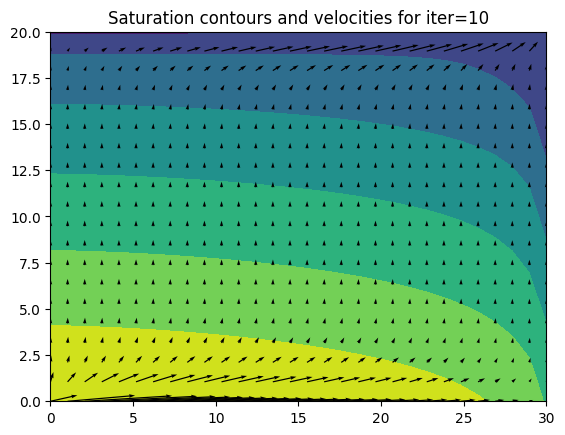

In [17]:
S3D = Sat.reshape((Nx,Ny,Nz),order='F')
SV_plot(Lx,Ly,Lz,Nx,Ny,Nz,S3D,Vx,Vy,Vz,10)

## Plotting:

In [18]:
def PV_plot(Lx,Ly,Lz,Nx,Ny,Nz,P,Vx,Vy,Vz):

    XX = np.linspace(0,Lx,Nx)
    YY = np.linspace(0,Ly,Ny)
    ZZ = np.linspace(0,Lz,Nz)

    # Define center velocities:
    VcX = np.zeros((Nx, Ny, Nz))
    VcY = np.zeros((Nx, Ny, Nz))
    VcZ = np.zeros((Nx, Ny, Nz))
    VcX[0:Nx,:,:] = (Vx[0:Nx,:,:]+Vx[1:Nx+1,:,:])/2
    VcY[:,0:Ny,:] = (Vy[:,0:Ny,:]+Vy[:,1:Ny+1,:])/2
    VcZ[:,:,0:Nz] = (Vz[:,:,0:Nz]+Vz[:,:,1:Nz+1])/2


    # Define a slice location to allow 2D plots:
    sliceat = int(np.floor(Nz/2))
    P_2D = np.squeeze(P[:,:,sliceat]).transpose()
    Vx_2D = np.squeeze(VcX[:,:,sliceat]).transpose()
    Vy_2D = np.squeeze(VcY[:,:,sliceat]).transpose()

    plt.figure()
    # Pressure plot:
    plt.contourf(XX,YY,P_2D)
    plt.colorbar()
    # Velocity field:
    plt.quiver(XX,YY,Vx_2D,Vy_2D)
    # Labels and titles:
    plt.xlabel('x(m)')
    plt.ylabel('y(m)')
    title = 'Pressure contours for z = '+str(ZZ[sliceat])+'m'
    plt.title(title)

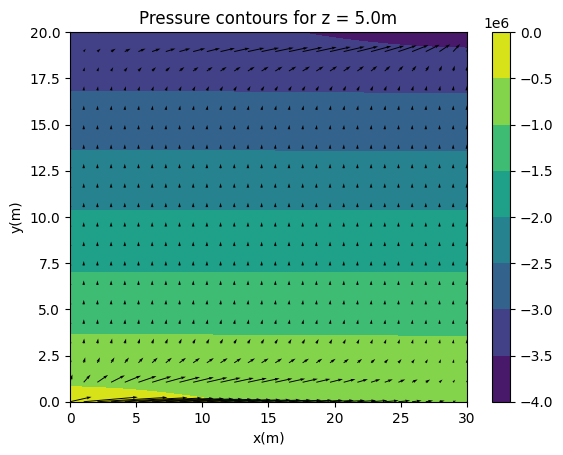

In [19]:
PV_plot(Lx,Ly,Lz,Nx,Ny,Nz,P,Vx,Vy,Vz)

Simple test of animating contour plots:

AttributeError: 'QuadContourSet' object has no attribute 'collections'

Error in callback <function _draw_all_if_interactive at 0x7bb6f245cae0> (for post_execute):


AttributeError: 'QuadContourSet' object has no attribute 'collections'

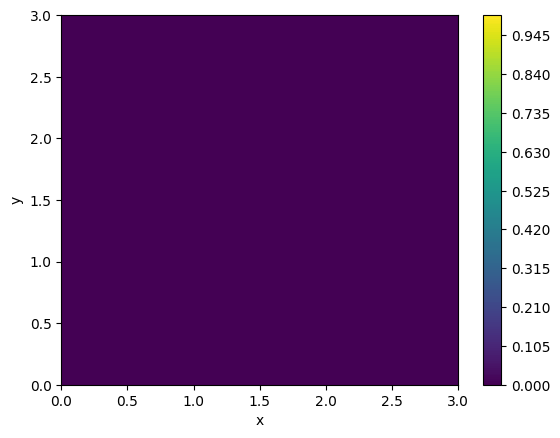

In [20]:
# Generate data for plotting
Lx = Ly = 3
Nx = Ny = 11
Nt = 200
x = np.linspace(0, Lx, Nx)
y = np.linspace(0, Ly, Ny)
x,y = np.meshgrid(x,y)
z0 = np.exp(-(x-Lx/2)**2-(y-Ly/2)**2)   # 2 dimensional Gaussian

def some_data(i):   # function returns a 2D data array
    return z0 * (i/Nt)

fig = plt.figure()
ax = plt.axes(xlim=(0, Lx), ylim=(0, Ly), xlabel='x', ylabel='y')

cvals = np.linspace(0,1,Nt+1)      # set contour values
cont = plt.contourf(x, y, some_data(0), cvals)    # first image on screen
plt.colorbar()

# animation function
def animate(i):
    global cont
    z = some_data(i)
    for c in cont.collections:
        c.remove()  # removes only the contours, leaves the rest intact
    cont = plt.contourf(x, y, z, cvals)
    plt.title('t = %i:  %.2f' % (i,z[5,5]))
    return cont

anim = animation.FuncAnimation(fig, animate, frames=Nt, repeat=False)
anim.save('animation.mp4', writer=animation.FFMpegWriter())


In [ ]:
plt.ion(); plt.figure(2);
for k in range(10):
    plt.clf();

    plt.subplot(121);
    plt.contourf(np.random.randn(10,10)); plt.colorbar();

    plt.subplot(122,polar=True)
    plt.contourf(np.random.randn(10,10)); plt.colorbar();

    plt.draw();

In [ ]:
def pltsin(ax, colors=['b']):
    x = np.linspace(0,1,100)
    if ax.lines:
        for line in ax.lines:
            line.set_xdata(x)
            y = np.random.random(size=(100,1))
            line.set_ydata(y)
    else:
        for color in colors:
            y = np.random.random(size=(100,1))
            ax.plot(x, y, color)
    fig.canvas.draw()

fig,ax = plt.subplots(1,1)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_xlim(0,1)
ax.set_ylim(0,1)
for f in range(15):
    pltsin(ax, ['b', 'r'])
    time.sleep(1)

Some tests with SciPy sparse matrix definitions:

In [ ]:
maindiag = np.arange(6,12)
oneabove = np.arange(12,17)
onebelow = np.arange(1,6)

diags = [maindiag[0:-2], maindiag, maindiag[2:]]
locations = [-2,0,2]

testspA = sp.diags(diags, locations)

fullA = testspA.toarray()
# print(fullA)